# Hands-On Session 2C: GRU for InSAR Deformation Time Series Forecasting
**GeoAI for Earth Observation Workshop — Day 2**

Bangkok sits on thick soft alluvial sediments that are compacting under the weight of rapid urban
development, and groundwater extraction accelerates the process. InSAR — Interferometric Synthetic
Aperture Radar — measures ground surface displacement with millimetre precision by comparing the
phase of radar waves returning from successive Sentinel-1 satellite passes. The result is a
**time series of vertical displacement** at every coherent pixel across the city, spanning years.

In this session we train a **Gated Recurrent Unit (GRU)** network to learn those temporal dynamics
and forecast **3–4 steps into the future**. This is a **regression** task: given the past 30
displacement observations at a pixel, predict the displacement at the next 4 acquisition dates.

**Learning objectives:**
- Load and explore a real InSAR HDF5 time series (322 dates, ~2744 × 2746 pixels)
- Apply quality filters to select reliable pixels for training
- Build sliding-window input/output pairs — the universal recipe for sequence forecasting
- Implement a multi-output GRU forecaster in PyTorch and understand each architectural choice
- Evaluate forecast skill with MAE and RMSE, both globally and per forecast step
- Visualise spatial forecast maps — predicted displacement for future acquisition dates

**Data:** `Data/BKK_VelocityMap/TimeSeries/enu_final_result_vY.h5`
**Model:** Multi-output GRU — predict 4 steps from a 30-step lookback window
**Units:** millimetres (mm), negative = subsidence (ground moving away from satellite)


## Section 1: Setup and Data Loading

We start by importing the required libraries and reading metadata from the HDF5 file.
[HDF5](https://www.hdfgroup.org/solutions/hdf5/) is a hierarchical binary format designed for
large scientific arrays. Its key feature for us is **lazy loading**: we can read any sub-array
(a spatial patch, a time slice) without pulling the full 10 GB array into RAM.

The file contains:

| Dataset | Shape / Type | Description |
|---------|-------------|-------------|
| `up` | (322, 2744, 2746) float32 | Vertical displacement in **mm** |
| `imdates` | (322,) bytes | Acquisition dates, format `YYYYMMDD` |
| `corner_lat` / `corner_lon` | scalar | Top-left corner coordinates |
| `post_lat` / `post_lon` | scalar | Pixel spacing in degrees (post_lat < 0) |

We open the file to inspect its contents and parse the date axis before loading any displacement data.


In [1]:
# !pip -q install gdown

import gdown

file_id = "13jImR_QnSE5NTKxAEN25N4sAChQy55w4"
output = "enu_final_result_vY.h5"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output,
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=13jImR_QnSE5NTKxAEN25N4sAChQy55w4
From (redirected): https://drive.google.com/uc?id=13jImR_QnSE5NTKxAEN25N4sAChQy55w4&confirm=t&uuid=b9a0f947-77c6-43be-8d32-5e1bbaa809f6
To: /content/enu_final_result_vY.h5
100%|██████████| 2.95G/2.95G [00:29<00:00, 99.2MB/s]


'enu_final_result_vY.h5'

In [2]:
import warnings
warnings.filterwarnings('ignore')

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {len(gpus)}")
print(f"Using device       : {'GPU' if gpus else 'CPU'}")



TensorFlow version : 2.20.0
GPUs available     : 1
Using device       : GPU


In [3]:

# ── Path to the InSAR time series HDF5 file ──────────────────────────────────
H5_PATH = Path("enu_final_result_vY.h5")
print(f"\nData file exists: {H5_PATH.exists()}")

# ── Inspect file structure and load metadata ──────────────────────────────────
with h5py.File(H5_PATH, 'r') as f:
    print("\nDatasets / groups inside the file:")
    def _print_item(name, obj):
        shape = getattr(obj, 'shape', '(group)')
        dtype = getattr(obj, 'dtype', '')
        print(f"  {name:<30} {str(shape):<20} {dtype}")
    f.visititems(_print_item)

    raw_dates  = f['imdates'][:]
    corner_lat = float(f['corner_lat'][()])
    corner_lon = float(f['corner_lon'][()])
    post_lat   = float(f['post_lat'][()])   # negative: grid goes southward
    post_lon   = float(f['post_lon'][()])   # positive: grid goes eastward
    T, nrows, ncols = f['up'].shape

# ── Parse dates from YYYYMMDD integers or byte strings ───────────────────────
def parse_imdates(raw):
    out = []
    for d in raw:
        s = d.decode() if isinstance(d, (bytes, bytearray)) else str(int(d))
        out.append(datetime.strptime(s, '%Y%m%d'))
    return out

dates     = parse_imdates(raw_dates)
date_nums = np.array([mdates.date2num(d) for d in dates])
revisits  = np.diff(date_nums)

print(f"\nTime series  : {T} acquisitions")
print(f"  Start date  : {dates[0].strftime('%Y-%m-%d')}")
print(f"  End date    : {dates[-1].strftime('%Y-%m-%d')}")
print(f"  Avg revisit : {revisits.mean():.1f} days  "
      f"(min {revisits.min():.0f}, max {revisits.max():.0f})")
print(f"\nSpatial grid : {nrows} rows × {ncols} cols")
print(f"Corner (lat, lon) : ({corner_lat:.4f}°, {corner_lon:.4f}°)")
print(f"Pixel spacing     : Δlat={post_lat:.6f}°, Δlon={post_lon:.6f}°")


Data file exists: True

Datasets / groups inside the file:
  E.geo                          (2744, 2746)         float32
  N.geo                          (2744, 2746)         float32
  U.geo                          (2744, 2746)         float32
  bperp                          (322,)               float64
  coh_avg                        (2744, 2746)         float32
  corner_lat                     ()                   float64
  corner_lon                     ()                   float64
  demerr_flag                    ()                   int64
  deramp_flag                    ()                   object
  east                           (322, 2744, 2746)    float32
  filtwidth_km                   ()                   float64
  filtwidth_yr                   ()                   float64
  gap                            (321, 2744, 2746)    int8
  hgt                            (2744, 2746)         float32
  hgt_linear_flag                ()                   int64
  imdates         

## Section 2: Loading a Spatial Patch and Exploring the Data

The full `up` array is approximately **10 GB** in float32 — loading it entirely would exhaust most
laptop RAM. Instead, we read a **300 × 300 pixel window** from the centre of the study area using
HDF5 array slicing: `f['up'][:, r1:r2, c1:c2]`. This loads only the data we need.

> **Best practice for large geospatial data:**
> Always read only the spatial/temporal slice you need. HDF5, NetCDF, and Zarr all support this
> natively. Never do `arr = f['dataset'][:]` on multi-GB arrays.

From the patch we compute three diagnostic maps:
- **Mean displacement** — the time-averaged vertical position (captures long-term trend)
- **Temporal standard deviation** — variability over time (proxy for deformation signal strength)
- **NaN fraction** — proportion of missing acquisitions per pixel (data quality indicator)


Loading patch: rows 1200–1500, cols 1200–1500
Patch pixels : 300 × 300 = 90,000
Reading from HDF5 (may take a few seconds)...

Patch shape         : (322, 300, 300)  (T × rows × cols)
Valid pixels        : 90,000
Displacement range  : -364.3 mm to 377.6 mm


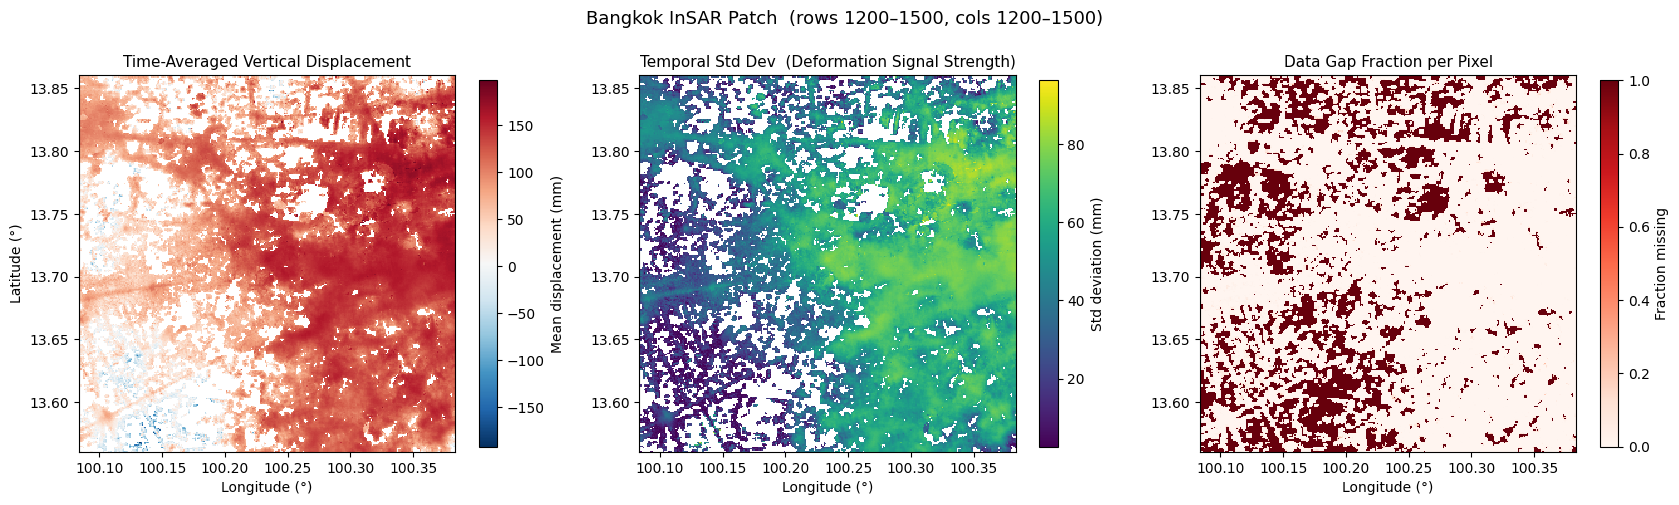


Observations:
  Minimum mean displacement : -191.8 mm  (strongest subsidence)
  Maximum mean displacement : 197.5 mm
  Mean temporal std dev     : 48.9 mm
  Pixels with >10% NaN      : 23.9%


In [4]:
# ── Spatial patch selection ───────────────────────────────────────────────────
# Adjust these to explore different sub-regions of Bangkok
ROW_START, ROW_END = 1200, 1500   # rows within the 2744-row grid
COL_START, COL_END = 1200, 1500   # cols within the 2746-col grid
PATCH_H = ROW_END - ROW_START
PATCH_W = COL_END - COL_START

print(f"Loading patch: rows {ROW_START}–{ROW_END}, cols {COL_START}–{COL_END}")
print(f"Patch pixels : {PATCH_H} × {PATCH_W} = {PATCH_H * PATCH_W:,}")
print("Reading from HDF5 (may take a few seconds)...")

with h5py.File(H5_PATH, 'r') as f:
    patch = f['up'][:, ROW_START:ROW_END, COL_START:COL_END].astype(np.float32)
    # Shape: (T, PATCH_H, PATCH_W)

# LiCSBAS masks incoherent pixels with NaN. Replace exact-zero pixels that have
# zero variance (never change) — these are likely masked/no-data pixels.
all_zero_mask = np.all(patch == 0.0, axis=0)
patch[:, all_zero_mask] = np.nan

print(f"\nPatch shape         : {patch.shape}  (T × rows × cols)")
print(f"Valid pixels        : {np.sum(~all_zero_mask):,}")
print(f"Displacement range  : {np.nanmin(patch):.1f} mm to {np.nanmax(patch):.1f} mm")

# ── Compute summary maps ──────────────────────────────────────────────────────
mean_disp = np.nanmean(patch, axis=0)                      # (PATCH_H, PATCH_W)
std_disp  = np.nanstd( patch, axis=0)
nan_frac  = np.mean(np.isnan(patch), axis=0)

# Compute approximate lat/lon extent for axis labels
lats = corner_lat + post_lat * np.array([ROW_START, ROW_END])
lons = corner_lon + post_lon * np.array([COL_START, COL_END])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

im0 = axes[0].imshow(mean_disp, cmap='RdBu_r', interpolation='nearest',
                     extent=[lons[0], lons[1], lats[1], lats[0]])
plt.colorbar(im0, ax=axes[0], label='Mean displacement (mm)', shrink=0.85)
axes[0].set_title('Time-Averaged Vertical Displacement', fontsize=11)
axes[0].set_xlabel('Longitude (°)'); axes[0].set_ylabel('Latitude (°)')

im1 = axes[1].imshow(std_disp, cmap='viridis', interpolation='nearest',
                     extent=[lons[0], lons[1], lats[1], lats[0]])
plt.colorbar(im1, ax=axes[1], label='Std deviation (mm)', shrink=0.85)
axes[1].set_title('Temporal Std Dev  (Deformation Signal Strength)', fontsize=11)
axes[1].set_xlabel('Longitude (°)')

im2 = axes[2].imshow(nan_frac, cmap='Reds', vmin=0, vmax=1, interpolation='nearest',
                     extent=[lons[0], lons[1], lats[1], lats[0]])
plt.colorbar(im2, ax=axes[2], label='Fraction missing', shrink=0.85)
axes[2].set_title('Data Gap Fraction per Pixel', fontsize=11)
axes[2].set_xlabel('Longitude (°)')

plt.suptitle(f'Bangkok InSAR Patch  (rows {ROW_START}–{ROW_END}, cols {COL_START}–{COL_END})',
             fontsize=13)
plt.tight_layout()
plt.savefig('bkk_patch_overview.png', dpi=150)
plt.show()

print("\nObservations:")
print(f"  Minimum mean displacement : {np.nanmin(mean_disp):.1f} mm  (strongest subsidence)")
print(f"  Maximum mean displacement : {np.nanmax(mean_disp):.1f} mm")
print(f"  Mean temporal std dev     : {np.nanmean(std_disp):.1f} mm")
print(f"  Pixels with >10% NaN      : {np.mean(nan_frac > 0.1)*100:.1f}%")


### Exploring Individual Pixel Time Series

Before building any model, it is essential to look at the raw data. We select four pixels that
represent different deformation regimes and plot their full time series.

Understanding what the data **looks like** is the most important step in any machine-learning
pipeline. It tells you:
- What features might be useful (trend, seasonal signal, step changes)
- What the noise level is
- Whether the data are continuous or have large gaps that need special handling


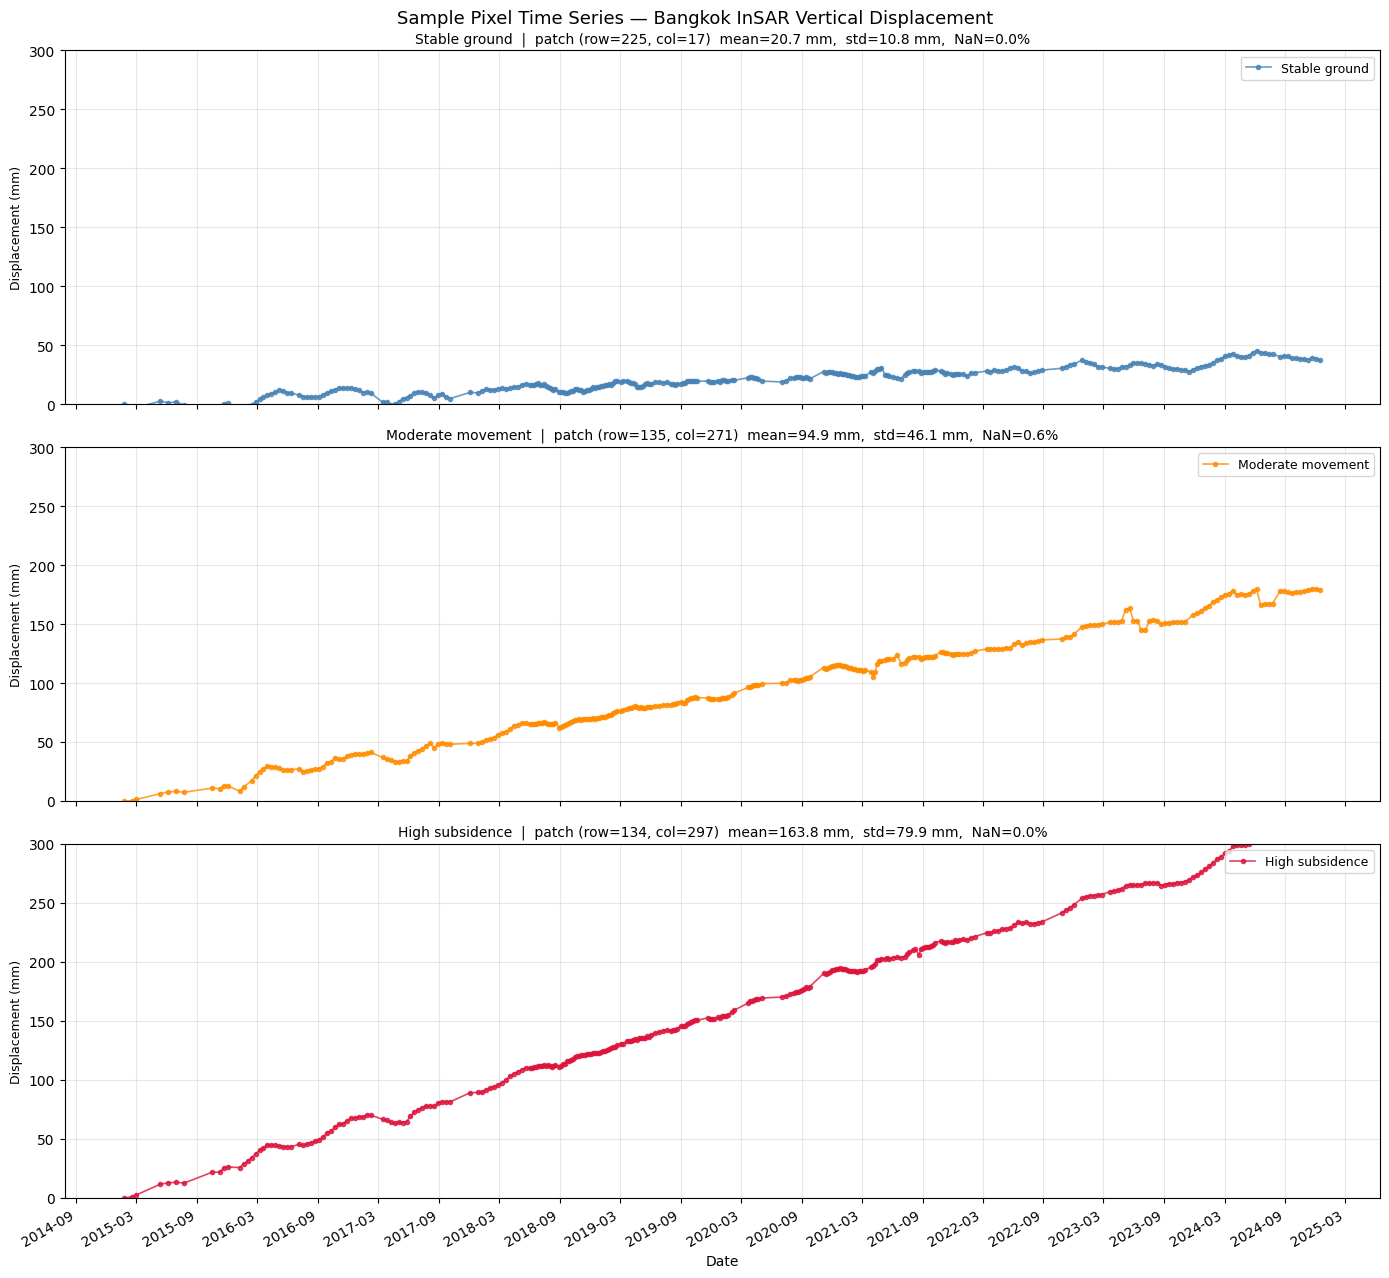

In [5]:
# ── Select representative pixels ──────────────────────────────────────────────
# We find pixels in different deformation regimes using percentile thresholds

# Filter: need good data quality (low NaN fraction)
good = nan_frac < 0.10

def find_pixel(condition, good_mask, default=(50, 50)):
    coords = np.argwhere(condition & good_mask)
    if len(coords) == 0:
        return default
    return coords[len(coords) // 2]   # pick the middle one

p_low  = find_pixel(mean_disp < np.nanpercentile(mean_disp, 10), good)
p_mid  = find_pixel((mean_disp > np.nanpercentile(mean_disp, 40)) &
                    (mean_disp < np.nanpercentile(mean_disp, 60)), good)
p_high = find_pixel(std_disp   > np.nanpercentile(std_disp, 90), good)

sample_pixels = [
    ('Stable ground',   p_low,  'steelblue'),
    ('Moderate movement',   p_mid,  'darkorange'),
    ('High subsidence',    p_high, 'crimson'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

for ax, (label, (r, c), color) in zip(axes, sample_pixels):
    ts    = patch[:, r, c]
    valid = ~np.isnan(ts)
    d_ok  = [d for d, v in zip(dates, valid) if v]
    t_ok  = ts[valid]

    ax.plot(d_ok, t_ok, 'o-', ms=3, lw=1.2, color=color, alpha=0.8)
    ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('Displacement (mm)', fontsize=9)
    ax.set_title(
        f'{label}  |  patch (row={r}, col={c})  '
        f'mean={np.nanmean(ts):.1f} mm,  std={np.nanstd(ts):.1f} mm,  '
        f'NaN={nan_frac[r, c]*100:.1f}%',
        fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend([label], loc='upper right', fontsize=9)
    ax.set_ylim(0,300)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[-1].set_xlabel('Date')
plt.suptitle('Sample Pixel Time Series — Bangkok InSAR Vertical Displacement', fontsize=13)
plt.ylim(0,300)
plt.tight_layout()
plt.savefig('bkk_sample_timeseries.png', dpi=150)
plt.show()


## Section 3: Pixel Selection and Preprocessing

### Why filter pixels?

Not every pixel in the patch is suitable for training a forecasting model:

- **Masked / incoherent pixels** (high NaN fraction): the InSAR phase could not be unwrapped
  reliably, usually over water, dense vegetation, or rapidly changing surfaces.
- **Flat / noise-dominated pixels** (low temporal std): the displacement is indistinguishable
  from measurement noise. There is nothing to learn from them.

We apply two filters:
1. **Completeness**: `NaN fraction ≤ 10%`
2. **Signal strength**: `temporal std dev ≥ 3 mm`  (above typical Sentinel-1 InSAR noise floor)

### Normalisation

After filtering, we **normalise each pixel's time series** to zero mean and unit standard
deviation, using statistics computed only on the training portion of the time axis. This is
critical because:

- Pixel displacements range from near-zero to tens of millimetres — without normalisation the
  loss would be dominated by the most strongly subsiding pixels.
- The GRU's sigmoid and tanh activations work best when inputs are roughly in [-3, 3].

> **Important:** We compute normalisation statistics (`μ`, `σ`) on the **training split only**,
> then apply them to validation and test. Using the full time series would leak future information.

### Time-axis split

| Split | Time steps | Date range | Fraction |
|-------|-----------|-----------|---------|
| Train | 0 → 239 | first ~75% | 75% |
| Val | 240 → 279 | next ~12% | 12% |
| Test | 280 → 321 | final ~13% | 13% |


In [6]:
# ── Quality filters ───────────────────────────────────────────────────────────
MAX_NAN_FRAC = 0.10   # at most 10% missing acquisitions
MIN_STD_MM   = 3.0    # minimum temporal std dev in mm

quality_mask = (nan_frac <= MAX_NAN_FRAC) & (std_disp >= MIN_STD_MM)
print(f"Pixels passing quality filter: {quality_mask.sum():,} / {quality_mask.size:,} "
      f"({quality_mask.mean()*100:.1f}%)")

# Get row/col indices of all selected pixels
sel_rows, sel_cols = np.where(quality_mask)

# Sub-sample to N_PIXELS for tractable training (adjust as needed)
N_PIXELS = 3000
if len(sel_rows) > N_PIXELS:
    rng_idx = np.random.choice(len(sel_rows), N_PIXELS, replace=False)
    sel_rows = sel_rows[rng_idx]
    sel_cols = sel_cols[rng_idx]

print(f"Pixels selected for training: {len(sel_rows):,}")

# ── Extract time series matrix ─────────────────────────────────────────────
# patch shape: (T, PATCH_H, PATCH_W)  →  ts_matrix shape: (N_pixels, T)
ts_matrix = patch[:, sel_rows, sel_cols].T.copy()   # (N_pixels, T)

# ── Interpolate small NaN gaps linearly ───────────────────────────────────────
# Some pixels may still have a few NaN points after the quality filter.
# Linear interpolation fills these gaps without distorting the trend.
def interpolate_nans(arr):
    out = arr.copy()
    for i in range(arr.shape[0]):
        y    = arr[i]
        nans = np.isnan(y)
        if nans.any() and (~nans).sum() >= 2:
            good_idx = np.where(~nans)[0]
            out[i, nans] = np.interp(np.where(nans)[0], good_idx, y[good_idx])
    return out

ts_matrix = interpolate_nans(ts_matrix)
print(f"Time series matrix shape: {ts_matrix.shape}  (N_pixels × T)")
print(f"Remaining NaN fraction  : {np.isnan(ts_matrix).mean()*100:.4f}%")

# ── Time-axis split ───────────────────────────────────────────────────────────
T_TRAIN = 240   # first 240 time steps → training
T_VAL   = 280   # steps 240–279 → validation; steps 280–321 → test

print(f"\nTrain : t=0..{T_TRAIN-1}   ({dates[0].strftime('%Y-%m-%d')} "
      f"to {dates[T_TRAIN-1].strftime('%Y-%m-%d')})")
print(f"Val   : t={T_TRAIN}..{T_VAL-1}   ({dates[T_TRAIN].strftime('%Y-%m-%d')} "
      f"to {dates[T_VAL-1].strftime('%Y-%m-%d')})")
print(f"Test  : t={T_VAL}..{T-1}   ({dates[T_VAL].strftime('%Y-%m-%d')} "
      f"to {dates[-1].strftime('%Y-%m-%d')})")

# ── Per-pixel normalisation (computed on training split only) ─────────────────
ts_train = ts_matrix[:, :T_TRAIN]
mu  = ts_train.mean(axis=1, keepdims=True)    # (N_pixels, 1)
sig = ts_train.std( axis=1, keepdims=True) + 1e-6  # avoid divide-by-zero

ts_norm = (ts_matrix - mu) / sig   # (N_pixels, T)

print(f"\nNormalised training data: mean={ts_norm[:, :T_TRAIN].mean():.4f}, "
      f"std={ts_norm[:, :T_TRAIN].std():.4f}  (should be ≈0 and ≈1)")
print(f"Mean pixel std dev (sig) : {sig.mean():.2f} mm  "
      f"(use to convert normalised errors back to mm)")


Pixels passing quality filter: 68,459 / 90,000 (76.1%)
Pixels selected for training: 3,000
Time series matrix shape: (3000, 322)  (N_pixels × T)
Remaining NaN fraction  : 0.0000%

Train : t=0..239   (2015-01-25 to 2021-12-19)
Val   : t=240..279   (2021-12-31 to 2023-07-18)
Test  : t=280..321   (2023-07-30 to 2024-12-15)

Normalised training data: mean=-0.0000, std=1.0000  (should be ≈0 and ≈1)
Mean pixel std dev (sig) : 35.66 mm  (use to convert normalised errors back to mm)


## Section 4: Sliding-Window Dataset for Multi-Step Forecasting

### The sliding window concept

A time series cannot be fed directly to a neural network as a single sample — it has variable
length and the model needs to learn from many examples. The **sliding window** technique solves
this by extracting overlapping sub-sequences from every pixel's time series.

Given a window of size `LOOKBACK + FORECAST_HORIZON`, we split it into:

```
Index:   t   t+1  ...  t+L-1 | t+L  t+L+1 ... t+L+H-1
          ←───── INPUT ──────→   ←──── TARGET ─────────→
          (past L steps)          (next H steps to predict)
```

With **L = 30** (lookback) and **H = 4** (forecast horizon):

- **Input X**: shape `(30, 1)` — 30 past displacement values
- **Target y**: shape `(4,)` — 4 future displacement values to predict

Windows from **all N_pixels pixels are pooled together**. This gives the model many training
examples and encourages it to learn patterns that generalise across the city rather than
overfitting to a single pixel.

> **Why 30 steps?**
> With an average revisit of ~12 days, 30 acquisitions span roughly **one year** — long enough to
> capture seasonal signals and trend changes that are the dominant features of Bangkok subsidence.

### The Dataset class

We implement a PyTorch `Dataset` that handles window extraction automatically. During training,
the `DataLoader` will sample random batches from this dataset.


Training windows   : 621,000
Validation windows : 21,000
Test windows       : 27,000

Input shape per sample  : (30, 1)  (Lookback, Features)
Target shape per sample : (4,)  (Forecast horizon)


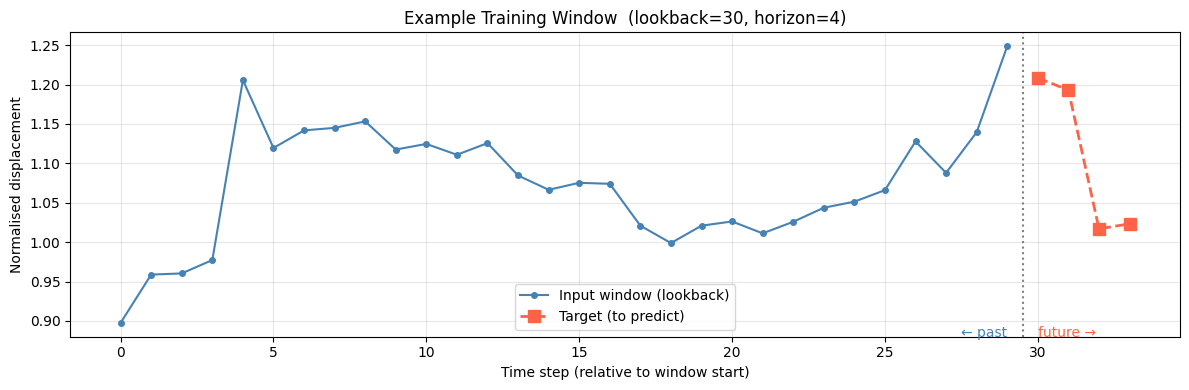

In [7]:
LOOKBACK         = 30   # number of past acquisitions fed to the GRU
FORECAST_HORIZON = 4    # number of future acquisitions to predict
BATCH_SIZE       = 512  # samples per mini-batch


def build_windows(ts_norm, t_start, t_end, lookback, horizon):
    """
    Extract overlapping (input, target) windows from all pixel time series.

    Returns
    -------
    X : ndarray (N, lookback, 1) float32 — input windows with a feature dimension
    y : ndarray (N, horizon)     float32 — target values to predict
    """
    xs, ys = [], []
    for ts in ts_norm:
        for i in range(t_start, t_end - lookback - horizon + 1):
            xs.append(ts[i          : i + lookback])
            ys.append(ts[i + lookback : i + lookback + horizon])
    X = np.array(xs, dtype=np.float32)[..., np.newaxis]  # (N, L, 1)
    y = np.array(ys, dtype=np.float32)
    return X, y


# ── Build numpy window arrays ──────────────────────────────────────────────
X_train, y_train = build_windows(ts_norm, 0,       T_TRAIN, LOOKBACK, FORECAST_HORIZON)
X_val,   y_val   = build_windows(ts_norm, T_TRAIN, T_VAL,   LOOKBACK, FORECAST_HORIZON)
X_test,  y_test  = build_windows(ts_norm, T_VAL,   T,       LOOKBACK, FORECAST_HORIZON)

# ── Wrap in tf.data.Dataset for efficient batching ─────────────────────────
train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
              .shuffle(len(X_train), seed=42)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

val_ds_tf  = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

test_ds_tf = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
               .batch(BATCH_SIZE))

print(f"Training windows   : {len(X_train):,}")
print(f"Validation windows : {len(X_val):,}")
print(f"Test windows       : {len(X_test):,}")
print(f"\nInput shape per sample  : {X_train[0].shape}  (Lookback, Features)")
print(f"Target shape per sample : {y_train[0].shape}  (Forecast horizon)")

# ── Visualise one example window ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
x_ex = X_train[800].squeeze()
y_ex = y_train[800]
t_in  = np.arange(LOOKBACK)
t_out = np.arange(LOOKBACK, LOOKBACK + FORECAST_HORIZON)

ax.plot(t_in,  x_ex, 'o-',
        color='steelblue', ms=4, lw=1.5, label='Input window (lookback)')
ax.plot(t_out, y_ex, 's--',
        color='tomato',    ms=8, lw=2.0, label='Target (to predict)')
ax.axvline(LOOKBACK - 0.5, color='gray', ls=':', lw=1.5)
ax.annotate('← past', xy=(LOOKBACK-1, ax.get_ylim()[0]), fontsize=10, ha='right', color='steelblue')
ax.annotate('future →', xy=(LOOKBACK, ax.get_ylim()[0]), fontsize=10, ha='left', color='tomato')
ax.set_xlabel('Time step (relative to window start)')
ax.set_ylabel('Normalised displacement')
ax.set_title(f'Example Training Window  (lookback={LOOKBACK}, horizon={FORECAST_HORIZON})')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('example_window.png', dpi=150)
plt.show()


## Section 5: GRU Architecture for Multi-Step Forecasting

### What is a GRU?

A **Gated Recurrent Unit (GRU)** is a type of recurrent neural network (RNN) designed to model
sequential data. It processes one time step at a time, maintaining a **hidden state** *h* that
serves as a compact memory of everything seen so far.

Unlike a plain RNN, which suffers from the **vanishing gradient problem** (losing information from
distant past steps during backpropagation), the GRU uses two learned *gates* to control
information flow:

| Gate | Symbol | Role |
|------|--------|------|
| **Reset gate** | *r* | How much of the previous hidden state to *forget* |
| **Update gate** | *z* | How much new vs. old information to keep |

The update equations at each timestep *t* are:

```
r_t  = σ(W_r · [h_{t-1}, x_t])            ← reset gate
z_t  = σ(W_z · [h_{t-1}, x_t])            ← update gate
h̃_t  = tanh(W · [r_t ⊙ h_{t-1}, x_t])    ← candidate new state
h_t  = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t  ← new hidden state
```

When the **update gate *z*** is close to 1, the hidden state is carried forward almost unchanged —
the GRU effectively remembers. When it is close to 0, the state is updated aggressively.
This is what allows GRUs to retain seasonal and trend information across ~30 time steps.

### Architecture: direct multi-output forecasting

Our model uses a **direct multi-output** strategy: a single forward pass produces all 4 future
values simultaneously from the GRU's final hidden state. This is more stable than autoregressive
forecasting (where each prediction is fed back as the next input), especially for short horizons.

```
Input (B, 30, 1)
       ↓
  keras.layers.GRU(64, return_sequences=True)   ← layer 1, passes all hidden states forward
       ↓
  keras.layers.GRU(64, return_sequences=False)  ← layer 2, emits only the LAST hidden state
       ↓
  Last hidden state  (B, 64)
       ↓
  Dense(32, activation='relu') + Dropout
       ↓
  Dense(4)
       ↓
Output (B, 4)  ← predicted displacements at t+1, t+2, t+3, t+4
```

In Keras, `return_sequences=False` (the default) causes a GRU layer to output only the hidden
state at the **last** timestep — exactly equivalent to `out[:, -1, :]` in PyTorch. The first GRU
layer must use `return_sequences=True` so it passes all hidden states to the second layer.


In [8]:
def build_gru_model(lookback, input_size=1, hidden_size=64, num_layers=2,
                    forecast_horizon=4, dropout=0.2):
    """
    Multi-step ahead GRU forecaster built with the Keras functional API.

    Stacked GRU layers read the full input sequence. The hidden state at the
    LAST timestep (return_sequences=False on the final GRU) is passed through
    a small Dense regression head to predict all forecast_horizon steps at once.

    Parameters
    ----------
    lookback         : number of input timesteps
    input_size       : features per timestep (1 for univariate displacement)
    hidden_size      : GRU units per layer
    num_layers       : number of stacked GRU layers
    forecast_horizon : number of future steps to predict simultaneously
    dropout          : dropout rate applied inside GRU and the Dense head
    """
    inputs = keras.Input(shape=(lookback, input_size), name='displacement_input')
    x = inputs

    for layer_idx in range(num_layers):
        # All layers except the last must return the full sequence so that
        # the next GRU layer receives hidden states for every timestep.
        return_seq = (layer_idx < num_layers - 1)
        x = keras.layers.GRU(
            hidden_size,
            return_sequences = return_seq,
            dropout          = dropout,
            name             = f'gru_{layer_idx + 1}'
        )(x)

    # Regression head: last hidden state → forecast_horizon outputs
    x = keras.layers.Dense(hidden_size // 2, activation='relu', name='head_dense')(x)
    x = keras.layers.Dropout(dropout, name='head_dropout')(x)
    outputs = keras.layers.Dense(forecast_horizon, name='forecast')(x)

    return keras.Model(inputs, outputs, name='GRUForecaster')


# ── Instantiate and inspect the model ─────────────────────────────────────
model = build_gru_model(
    lookback         = LOOKBACK,
    input_size       = 1,
    hidden_size      = 64,
    num_layers       = 2,
    forecast_horizon = FORECAST_HORIZON,
    dropout          = 0.2
)

model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

# ── Sanity check: run a dummy batch through the model ─────────────────────
dummy_input  = tf.random.normal([8, LOOKBACK, 1])
dummy_output = model(dummy_input, training=False)

print(f"\nForward-pass check:")
print(f"  Input  shape: {dummy_input.shape}   (batch=8, lookback={LOOKBACK}, features=1)")
print(f"  Output shape: {dummy_output.shape}  (batch=8, horizon={FORECAST_HORIZON})")
print("  Forward pass OK.")


Model: "GRUForecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ displacement_input (InputLayer) │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,036 (156.39 KB)

 Trainable params: 40,036 (156.39 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 40,036

Forward-pass check:
  Input  shape: (8, 30, 1)   (batch=8, lookback=30, features=1)
  Output shape: (8, 4)  (batch=8, horizon=4)
  Forward pass OK.


## Section 6: Training the GRU

### Loss function: Mean Squared Error (MSE)

We minimise **MSE** across all 4 forecast steps:

$$\mathcal{L} = \frac{1}{N \cdot H} \sum_{i=1}^{N} \sum_{h=1}^{H} (\hat{y}_{i,h} - y_{i,h})^2$$

MSE penalises large errors quadratically — appropriate when large displacement forecast errors
are especially costly in practice (e.g., infrastructure risk assessment).

### Optimiser: AdamW

**AdamW** (Adam with decoupled weight decay) adapts the learning rate per parameter based on
gradient history, and regularises weights via L2 penalty. In Keras, it is available as
`keras.optimizers.AdamW`. We also pass `clipnorm=1.0` to clip gradient norms inside the
optimiser, which prevents exploding gradients common in recurrent networks.

### Learning rate schedule: cosine decay

`keras.optimizers.schedules.CosineDecay` smoothly reduces the learning rate from `lr = 1e-3`
to near zero over the total number of training steps. This helps the model converge into a
flat minimum without the abrupt drops of step-based schedulers.

### Early stopping

`keras.callbacks.EarlyStopping` monitors validation loss and stops training if it does not
improve for `PATIENCE` consecutive epochs, then restores the best weights automatically via
`restore_best_weights=True`.


Epoch 1/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.1749 - val_loss: 0.3482
Epoch 2/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.1592 - val_loss: 0.3957
Epoch 3/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.1572 - val_loss: 0.4281
Epoch 4/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.1562 - val_loss: 0.4072
Epoch 5/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.1571 - val_loss: 0.4220
Epoch 6/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.1548 - val_loss: 0.4317
Epoch 7/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.1549 - val_loss: 0.4843
Epoch 8/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.1541 - val_loss: 0.4670
Epoch 9/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.1545 - val_loss: 0.4682
Epoch 10/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.1542 - val_loss: 0.4730
Restoring model weights from the end of the best epoch: 1.

Training complete. Best validation MSE:

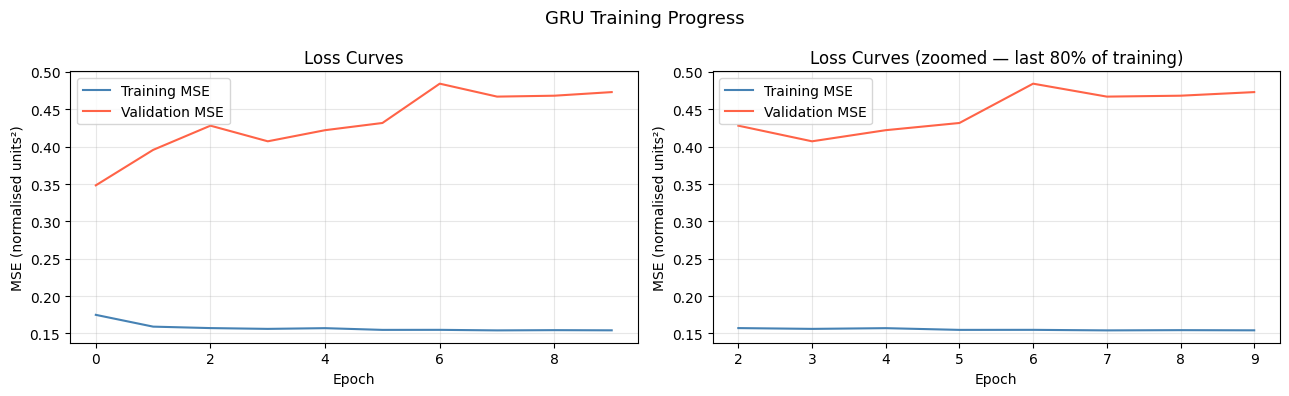

In [9]:
N_EPOCHS = 10
LR       = 1e-3
PATIENCE = 10   # stop if val loss doesn't improve for 10 epochs

# ── Cosine decay schedule over all training steps ─────────────────────────
steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
total_steps     = N_EPOCHS * steps_per_epoch

cosine_decay = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR,
    decay_steps           = total_steps,
    alpha                 = 1e-6   # minimum LR as a fraction of initial
)

# ── Compile ───────────────────────────────────────────────────────────────
model.compile(
    optimizer = keras.optimizers.AdamW(
        learning_rate = cosine_decay,
        weight_decay  = 1e-4,
        clipnorm      = 1.0   # gradient clipping — prevents exploding gradients in RNNs
    ),
    loss = 'mse'
)

# ── Callbacks ─────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = PATIENCE,
        restore_best_weights = True,
        verbose              = 1
    ),
]

# ── Train ─────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data = val_ds_tf,
    epochs          = N_EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

train_losses  = history.history['loss']
val_losses    = history.history['val_loss']
best_val_loss = min(val_losses)
print(f"\nTraining complete. Best validation MSE: {best_val_loss:.5f}")

# ── Plot training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, color='steelblue', label='Training MSE')
axes[0].plot(val_losses,   color='tomato',    label='Validation MSE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (normalised units²)')
axes[0].set_title('Loss Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

start_zoom = max(0, len(train_losses) // 5)
axes[1].plot(range(start_zoom, len(train_losses)),
             train_losses[start_zoom:], color='steelblue', label='Training MSE')
axes[1].plot(range(start_zoom, len(val_losses)),
             val_losses[start_zoom:],   color='tomato',    label='Validation MSE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (normalised units²)')
axes[1].set_title('Loss Curves (zoomed — last 80% of training)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('GRU Training Progress', fontsize=13)
plt.tight_layout()
plt.savefig('gru_training_curves.png', dpi=150)
plt.show()


## Section 7: Evaluation on the Test Set

We now evaluate the trained GRU on the **held-out test windows** — the acquisitions after `T_VAL`
that the model has never seen during training or hyperparameter selection.

### Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(|ŷ − y|) | Average absolute error — easy to interpret, robust to outliers |
| **RMSE** | √mean((ŷ − y)²) | Root mean squared error — penalises large errors more |

Both are reported in **normalised units**. To convert back to millimetres, multiply by the
mean per-pixel standard deviation (`mean(σ)`).

### Per-step analysis

We also compute MAE and RMSE for each of the 4 forecast steps separately. If the error grows
steeply from step 1 to step 4, the model struggles to maintain accuracy over the forecast horizon.
Gradual growth is expected and acceptable; a sharp jump suggests the model is extrapolating
beyond what it can learn from the training data.


── Overall Test Metrics ─────────────────────────────────────────────────
  MAE  (normalised) : 0.9177   ≈ 32.73 mm
  RMSE (normalised) : 0.9375  ≈ 33.43 mm
  (mean pixel σ used for back-conversion: 35.66 mm)

── Error by Forecast Step ──────────────────────────────────────────────
  Step +1: MAE  = 0.7967 (28.41 mm)  |  RMSE = 0.8053 (28.72 mm)
  Step +2: MAE  = 0.8237 (29.37 mm)  |  RMSE = 0.8354 (29.79 mm)
  Step +3: MAE  = 0.9695 (34.57 mm)  |  RMSE = 0.9829 (35.05 mm)
  Step +4: MAE  = 1.0810 (38.55 mm)  |  RMSE = 1.0968 (39.11 mm)


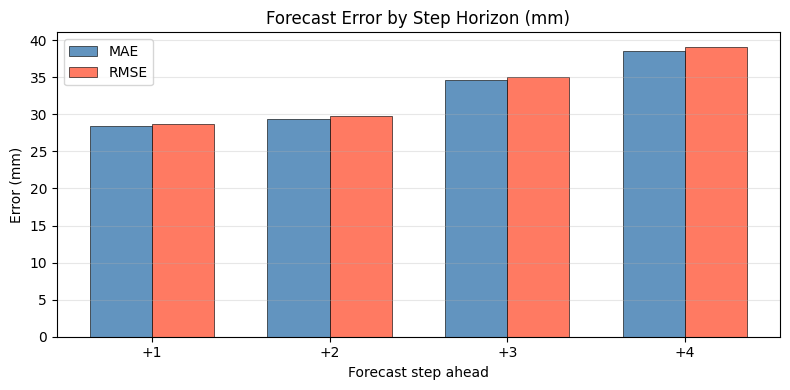

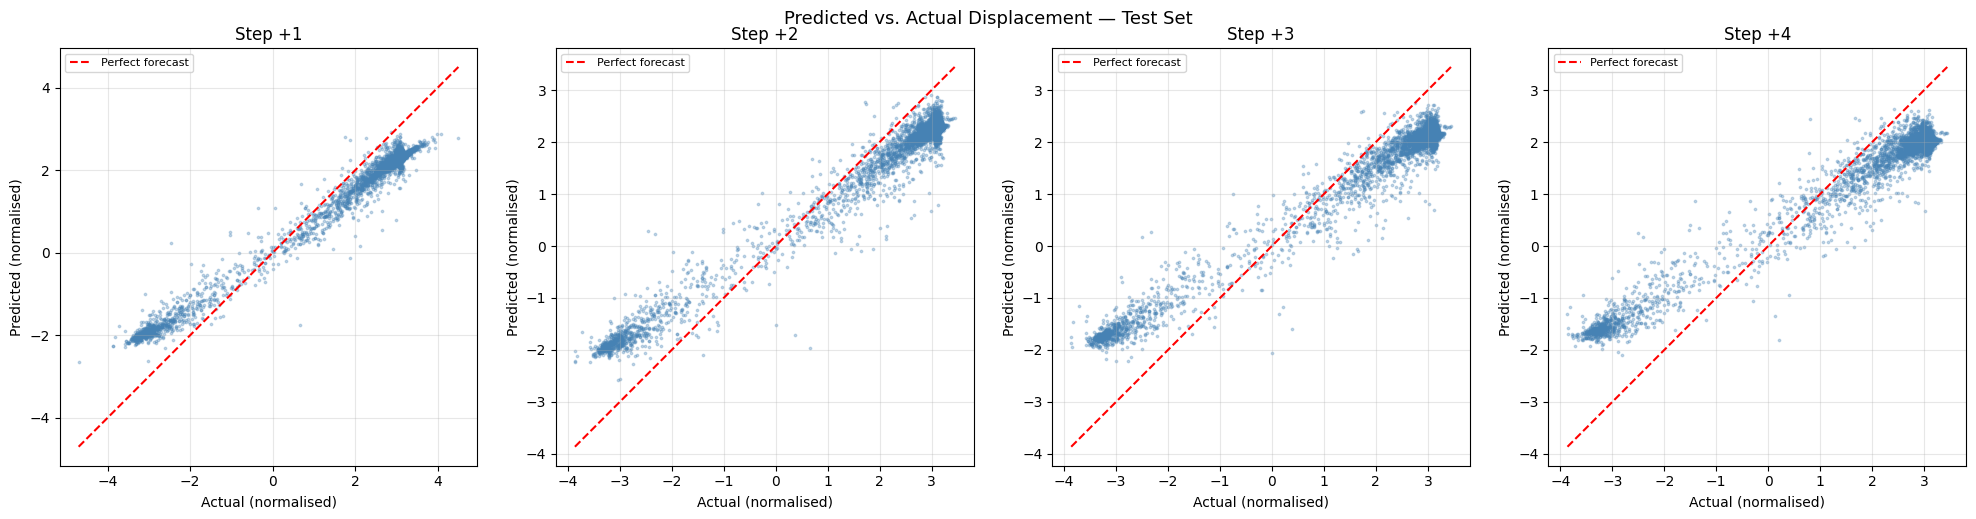

In [10]:
# ── Run predictions on the held-out test set ──────────────────────────────
preds   = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)  # (N_test, H)
targets = y_test                                                     # (N_test, H)

# ── Overall metrics ───────────────────────────────────────────────────────
mae  = np.mean(np.abs(preds - targets))
rmse = np.sqrt(np.mean((preds - targets) ** 2))
mean_sig_mm = float(sig.mean())   # average per-pixel σ for back-conversion to mm

print("── Overall Test Metrics ─────────────────────────────────────────────────")
print(f"  MAE  (normalised) : {mae:.4f}   ≈ {mae * mean_sig_mm:.2f} mm")
print(f"  RMSE (normalised) : {rmse:.4f}  ≈ {rmse * mean_sig_mm:.2f} mm")
print(f"  (mean pixel σ used for back-conversion: {mean_sig_mm:.2f} mm)")

# ── Per-step metrics ──────────────────────────────────────────────────────
step_mae  = np.mean(np.abs(preds - targets), axis=0)   # (H,)
step_rmse = np.sqrt(np.mean((preds - targets) ** 2, axis=0))

print("\n── Error by Forecast Step ──────────────────────────────────────────────")
for h in range(FORECAST_HORIZON):
    print(f"  Step +{h+1}: "
          f"MAE  = {step_mae[h]:.4f} ({step_mae[h] * mean_sig_mm:.2f} mm)  |  "
          f"RMSE = {step_rmse[h]:.4f} ({step_rmse[h] * mean_sig_mm:.2f} mm)")

# ── Bar chart: per-step error ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
steps = np.arange(1, FORECAST_HORIZON + 1)
width = 0.35
ax.bar(steps - width/2, step_mae  * mean_sig_mm, width=width,
       label='MAE',  color='steelblue', alpha=0.85, edgecolor='k', linewidth=0.5)
ax.bar(steps + width/2, step_rmse * mean_sig_mm, width=width,
       label='RMSE', color='tomato',    alpha=0.85, edgecolor='k', linewidth=0.5)
ax.set_xlabel('Forecast step ahead')
ax.set_ylabel('Error (mm)')
ax.set_xticks(steps)
ax.set_xticklabels([f'+{s}' for s in steps])
ax.set_title('Forecast Error by Step Horizon (mm)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_step_error.png', dpi=150)
plt.show()

# ── Predicted vs actual scatter for all test windows ─────────────────────
fig, axes = plt.subplots(1, FORECAST_HORIZON, figsize=(5 * FORECAST_HORIZON, 5))
for h, ax in enumerate(axes):
    ax.scatter(targets[:, h], preds[:, h], s=3, alpha=0.3, color='steelblue')
    lim_lo = min(targets[:, h].min(), preds[:, h].min())
    lim_hi = max(targets[:, h].max(), preds[:, h].max())
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', lw=1.5, label='Perfect forecast')
    ax.set_xlabel('Actual (normalised)')
    ax.set_ylabel('Predicted (normalised)')
    ax.set_title(f'Step +{h+1}')
    ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Predicted vs. Actual Displacement — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('pred_vs_actual_scatter.png', dpi=150)
plt.show()


### Qualitative Per-Pixel Forecast Comparison

Aggregate metrics tell us the average behaviour, but it is equally important to look at
**individual pixel forecasts** and compare the predicted time series against the observed values.

Here we take 6 randomly selected pixels and for each one:
1. Plot the **historical context** (last 60 acquisitions before the test split)
2. Mark the **actual** test-period values (green)
3. Show the **GRU forecast** starting from the last observed lookback window (red dashed)

The closer the red dashed line follows the green dots, the better the model is forecasting.


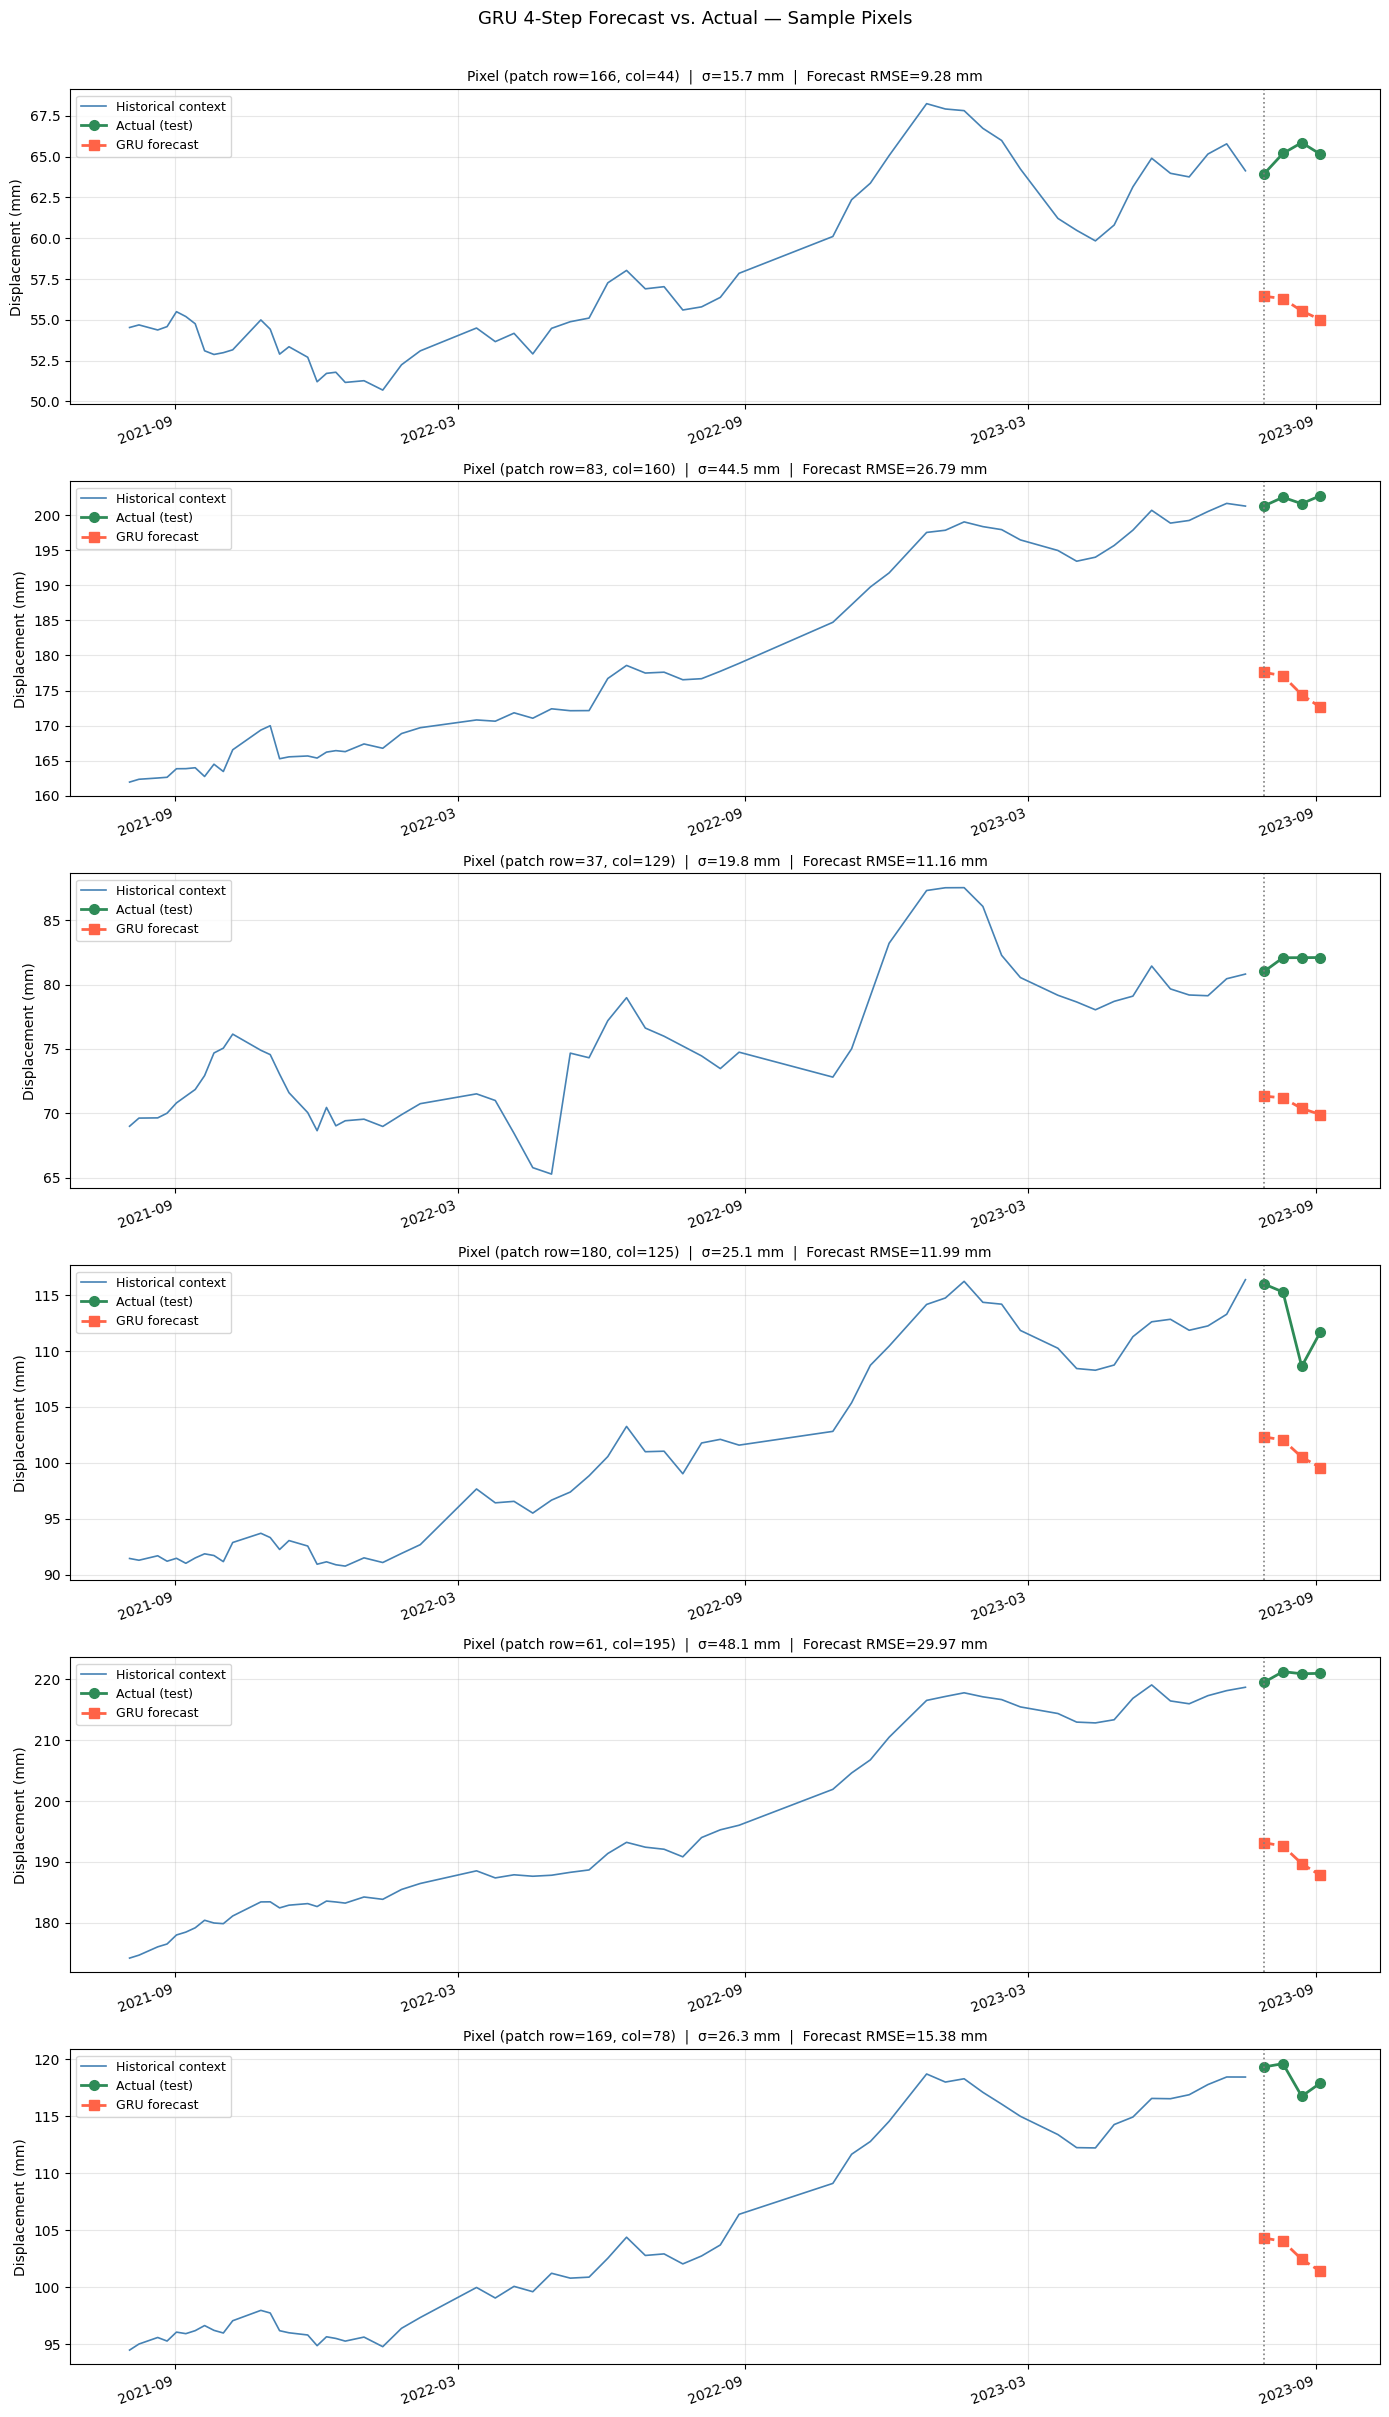

In [11]:
# ── Visualise GRU forecasts vs. actual for 6 sample pixels ────────────────
np.random.seed(7)
n_vis = 6
vis_idx = np.random.choice(len(sel_rows), n_vis, replace=False)

fig, axes = plt.subplots(n_vis, 1, figsize=(14, 4 * n_vis), sharex=False)

for ax_i, pix in enumerate(vis_idx):
    ts_raw = ts_matrix[pix]          # raw mm values, shape (T,)
    mu_p   = float(mu[pix, 0])
    sig_p  = float(sig[pix, 0])

    # Build lookback window ending at T_VAL (last observed date)
    input_window = ts_norm[pix, T_VAL - LOOKBACK : T_VAL]
    x_arr        = input_window[np.newaxis, :, np.newaxis].astype(np.float32)  # (1, L, 1)
    pred_norm    = model.predict(x_arr, verbose=0).squeeze()   # (H,)
    pred_mm      = pred_norm * sig_p + mu_p

    # Actual test values
    true_mm = ts_raw[T_VAL : T_VAL + FORECAST_HORIZON]
    t_true  = dates[T_VAL : T_VAL + FORECAST_HORIZON]

    # Context: last 60 steps before test split
    ctx_s  = max(0, T_VAL - 60)
    ctx_d  = dates[ctx_s : T_VAL]
    ctx_mm = ts_raw[ctx_s : T_VAL]

    ax = axes[ax_i]
    ax.plot(ctx_d,  ctx_mm,  '-',  color='steelblue', lw=1.2, label='Historical context')
    ax.plot(t_true, true_mm, 'o-', color='seagreen',  lw=2,   ms=7, label='Actual (test)')
    ax.plot(t_true, pred_mm, 's--', color='tomato',   lw=2,   ms=7, label='GRU forecast')
    ax.axvline(dates[T_VAL], color='gray', ls=':', lw=1.2)

    pixel_rmse = float(np.sqrt(np.mean((pred_mm - true_mm) ** 2)))
    r, c = sel_rows[pix], sel_cols[pix]
    ax.set_title(f'Pixel (patch row={r}, col={c})  |  '
                 f'σ={sig_p:.1f} mm  |  Forecast RMSE={pixel_rmse:.2f} mm',
                 fontsize=10)
    ax.set_ylabel('Displacement (mm)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('GRU 4-Step Forecast vs. Actual — Sample Pixels', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('gru_forecast_vs_actual.png', dpi=150)
plt.show()


## Section 8: Spatial Forecast Maps

One of the most powerful features of a pixel-wise forecasting approach is that predictions can
be **reassembled into a spatial map**. By applying the trained GRU to the lookback window ending
at the last observed date for every selected pixel, we generate a predicted displacement value
for each of the next 4 acquisitions.

The result is a set of **forecast maps** — spatial images showing the expected vertical
displacement over Bangkok at future dates. These can be compared directly with the last observed
displacement map to assess whether the model expects subsidence to accelerate, stabilise, or reverse.

> **Note on spatial awareness:**
> Our GRU processes each pixel **independently** — it has no explicit knowledge of its geographic
> neighbours. The spatial coherence in the forecast maps arises naturally because nearby pixels
> tend to have similar deformation histories, and similar histories produce similar forecasts.
> Adding spatial context (e.g., a CNN that processes a 3 × 3 neighbourhood) is a straightforward
> extension — see Exercise 4.


Forecasts computed for 3,000 pixels
Forecast range: -178.7 mm to 291.1 mm

Expected future acquisition dates:
  Step +1: 2024-12-26
  Step +2: 2025-01-06
  Step +3: 2025-01-17
  Step +4: 2025-01-29


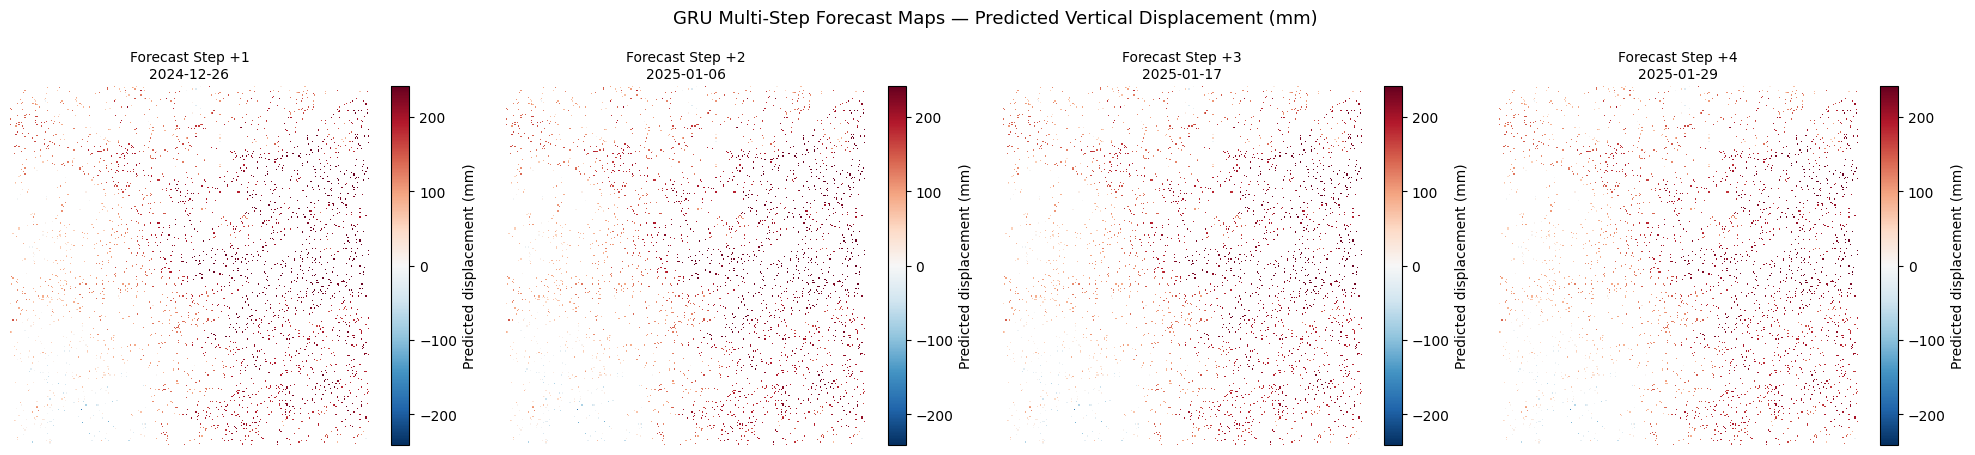

In [12]:
# ── Apply model to all selected pixels ───────────────────────────────────────
# Build the full input tensor: final LOOKBACK steps for every pixel
INFER_BATCH    = 1024
x_all          = ts_norm[:, -LOOKBACK:, np.newaxis].astype(np.float32)  # (N, L, 1)

forecasts_norm = model.predict(x_all, batch_size=INFER_BATCH, verbose=0)  # (N, H)

# Convert normalised predictions back to mm
# sig shape: (N_pixels, 1), mu shape: (N_pixels, 1)
forecasts_mm = forecasts_norm * sig[:, 0:1] + mu[:, 0:1]   # (N_pixels, H)

print(f"Forecasts computed for {len(sel_rows):,} pixels")
print(f"Forecast range: {forecasts_mm.min():.1f} mm to {forecasts_mm.max():.1f} mm")

# ── Rebuild spatial maps (patch grid) ─────────────────────────────────────────
forecast_maps = np.full((FORECAST_HORIZON, PATCH_H, PATCH_W), np.nan, dtype=np.float32)
for h in range(FORECAST_HORIZON):
    forecast_maps[h, sel_rows, sel_cols] = forecasts_mm[:, h]

# Estimate future acquisition dates
avg_revisit  = np.diff(date_nums).mean()
future_dates = [dates[-1] + timedelta(days=int(avg_revisit * (h + 1)))
                for h in range(FORECAST_HORIZON)]

print("\nExpected future acquisition dates:")
for h, fd in enumerate(future_dates):
    print(f"  Step +{h+1}: {fd.strftime('%Y-%m-%d')}")

# ── Plot the 4 forecast maps ──────────────────────────────────────────────────
vlim = max(abs(np.nanpercentile(forecast_maps,  5)),
           abs(np.nanpercentile(forecast_maps, 95)))

fig, axes = plt.subplots(1, FORECAST_HORIZON, figsize=(5 * FORECAST_HORIZON, 5))
for h, ax in enumerate(axes):
    im = ax.imshow(forecast_maps[h], cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Predicted displacement (mm)', shrink=0.82)
    ax.set_title(f'Forecast Step +{h+1}\n{future_dates[h].strftime("%Y-%m-%d")}',
                 fontsize=10)
    ax.axis('off')

plt.suptitle('GRU Multi-Step Forecast Maps — Predicted Vertical Displacement (mm)',
             fontsize=13)
plt.tight_layout()
plt.savefig('gru_spatial_forecast.png', dpi=150)
plt.show()


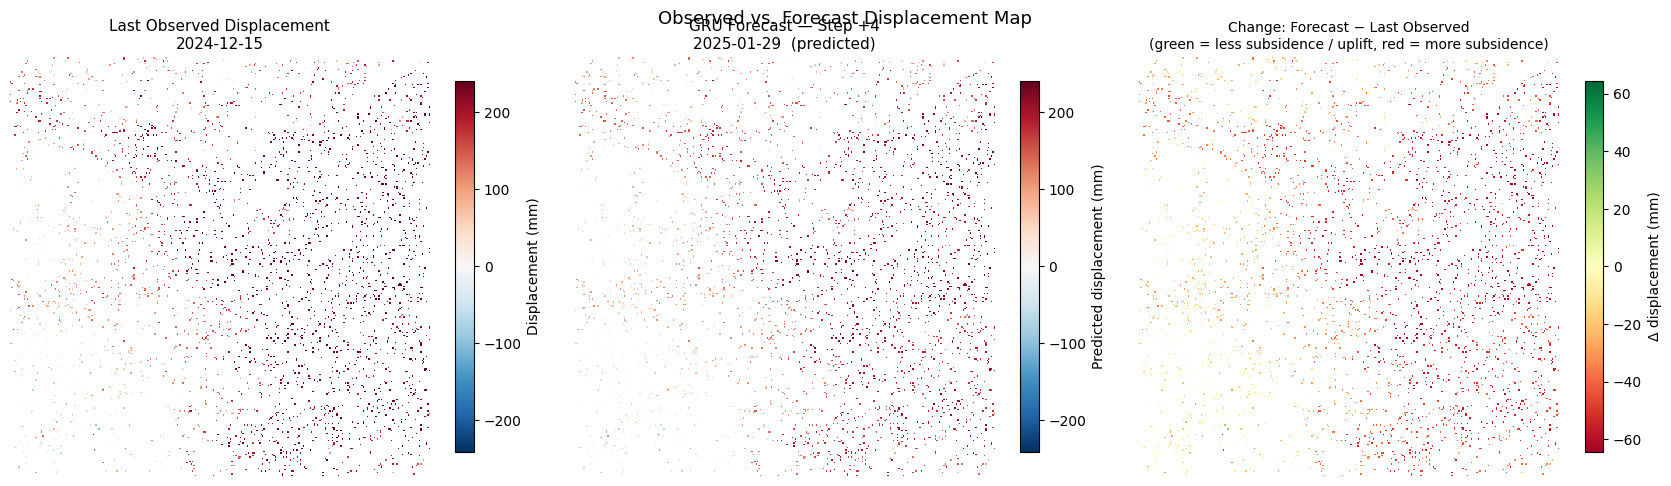

Spatial forecast maps saved.
Mean predicted displacement at step +4: 146.20 mm
Mean last observed displacement: 186.94 mm


In [13]:
# ── Compare last observation vs. 4-step forecast ──────────────────────────────
# This shows how the model expects the subsidence pattern to evolve

last_obs_map = np.full((PATCH_H, PATCH_W), np.nan, dtype=np.float32)
for pix in range(len(sel_rows)):
    r, c = sel_rows[pix], sel_cols[pix]
    last_obs_map[r, c] = ts_matrix[pix, -1]   # last observed value (raw mm)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

im0 = axes[0].imshow(last_obs_map, cmap='RdBu_r', vmin=-vlim, vmax=vlim,
                     interpolation='nearest')
plt.colorbar(im0, ax=axes[0], label='Displacement (mm)', shrink=0.85)
axes[0].set_title(f'Last Observed Displacement\n{dates[-1].strftime("%Y-%m-%d")}',
                  fontsize=11)
axes[0].axis('off')

im1 = axes[1].imshow(forecast_maps[-1], cmap='RdBu_r', vmin=-vlim, vmax=vlim,
                     interpolation='nearest')
plt.colorbar(im1, ax=axes[1], label='Predicted displacement (mm)', shrink=0.85)
axes[1].set_title(f'GRU Forecast — Step +{FORECAST_HORIZON}\n'
                  f'{future_dates[-1].strftime("%Y-%m-%d")}  (predicted)',
                  fontsize=11)
axes[1].axis('off')

# Difference map: forecast − last observation
diff_map = forecast_maps[-1] - last_obs_map
diff_lim = np.nanpercentile(np.abs(diff_map), 95)
im2 = axes[2].imshow(diff_map, cmap='RdYlGn', vmin=-diff_lim, vmax=diff_lim,
                     interpolation='nearest')
plt.colorbar(im2, ax=axes[2], label='Δ displacement (mm)', shrink=0.85)
axes[2].set_title(f'Change: Forecast − Last Observed\n'
                  f'(green = less subsidence / uplift, red = more subsidence)',
                  fontsize=10)
axes[2].axis('off')

plt.suptitle('Observed vs. Forecast Displacement Map', fontsize=13)
plt.tight_layout()
plt.savefig('obs_vs_forecast_comparison.png', dpi=150)
plt.show()

print("Spatial forecast maps saved.")
print(f"Mean predicted displacement at step +{FORECAST_HORIZON}: "
      f"{np.nanmean(forecast_maps[-1]):.2f} mm")
print(f"Mean last observed displacement: {np.nanmean(last_obs_map):.2f} mm")
